In [ ]:
"""
Data-Efficient DFL: Shortest Path (Stream-Based Version)

Methods:

supervise: Directly selects the first budget samples from the stream and labels them sequentially, without shuffling or selection.
Combined with the stream_clustering setting:
0.0 → the first budget samples are uniformly distributed (supervise performs reasonably well)
0.9 → the first budget samples come from one or two clusters (supervise wastes budget)
margin: Labels a sample only if margin < b_t (following Liu et al., Algorithm 1).
Selection is performed over the entire stream, allowing it to skip redundant samples and cover more clusters.
uncertainty / flip / regret: Heuristic active learning methods.

stream_clustering parameter:

0.0 = i.i.d., fully shuffled (paper setting; supervise already performs well)
1.0 = strictly clustered (supervise wastes budget significantly; active learning shows clear advantages)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import time
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# Part 1: Grid
# ============================================================

def build_grid(grid_size):
    n = grid_size
    n_h = n * (n - 1); n_v = (n - 1) * n; d = n_h + n_v
    total_steps = 2 * (n - 1)
    all_paths = []
    for right_pos in combinations(range(total_steps), n - 1):
        right_set = set(right_pos)
        edges = []; ci = cj = 0
        for step in range(total_steps):
            if step in right_set:
                edges.append(ci * (n-1) + cj); cj += 1
            else:
                edges.append(n_h + cj * (n-1) + ci); ci += 1
        all_paths.append(np.array(edges))
    return d, len(all_paths), all_paths


def solve_shortest_path(cost, gs):
    n = gs; d = len(cost); n_h = n*(n-1)
    h = np.zeros((n, n-1)); v = np.zeros((n-1, n))
    idx = 0
    for i in range(n):
        for j in range(n-1): h[i,j] = cost[idx]; idx += 1
    for j in range(n):
        for i in range(n-1): v[i,j] = cost[idx]; idx += 1
    INF = 1e18
    dist = np.full((n,n), INF); par = np.full((n,n,2), -1, dtype=int)
    dist[0,0] = 0
    for i in range(n):
        for j in range(n):
            if i==0 and j==0: continue
            if j>0 and dist[i,j-1]+h[i,j-1] < dist[i,j]:
                dist[i,j] = dist[i,j-1]+h[i,j-1]; par[i,j] = [i,j-1]
            if i>0 and dist[i-1,j]+v[i-1,j] < dist[i,j]:
                dist[i,j] = dist[i-1,j]+v[i-1,j]; par[i,j] = [i-1,j]
    w = np.zeros(d); ci = cj = n-1
    while not (ci==0 and cj==0):
        pi, pj = par[ci,cj]
        if pi==ci and pj==cj-1: w[ci*(n-1)+(cj-1)] = 1.0
        elif pi==ci-1 and pj==cj: w[n*(n-1)+cj*(n-1)+(ci-1)] = 1.0
        ci, cj = pi, pj
    return w


def solve_sp_torch(cost, gs):
    c = cost.detach().cpu().numpy()
    if c.ndim == 1:
        return torch.FloatTensor(solve_shortest_path(c, gs)).to(cost.device)
    return torch.FloatTensor(
        np.array([solve_shortest_path(ci, gs) for ci in c])
    ).to(cost.device)


def get_opt_path_idx(cost, gs, all_paths):
    w = solve_shortest_path(cost, gs)
    active = set(np.where(w > 0.5)[0])
    for i, p in enumerate(all_paths):
        if set(p) == active: return i
    return -1


# ============================================================
# Part 2: Data Generation
# ============================================================

def generate_B_matrix(p, d, gs, all_paths, margin_threshold=0.1,
                      max_attempts=1000, rng=None):
    if rng is None: rng = np.random.RandomState(42)
    n_paths = len(all_paths)
    thresholds_to_try = [margin_threshold, 0.01]

    for thresh in thresholds_to_try:
        for attempt in range(max_attempts):
            B = rng.binomial(1, 0.5, size=(d, p)).astype(np.float64)
            centers = []; ok = True
            for pi in range(n_paths):
                found = False
                for scale in [0.5, 1.0]:
                    for _ in range(100):
                        mu = rng.randn(p) * scale
                        cost = B @ mu
                        if get_opt_path_idx(cost, gs, all_paths) == pi:
                            w = solve_shortest_path(cost, gs)
                            oc = cost @ w
                            min_gap = np.inf
                            for pj, path in enumerate(all_paths):
                                if pj != pi:
                                    wp = np.zeros(d); wp[path] = 1.0
                                    g = cost @ wp - oc
                                    if g < min_gap: min_gap = g
                            if min_gap > thresh:
                                centers.append(mu); found = True; break
                    if found: break
                if not found: ok = False; break
            if ok:
                if thresh < margin_threshold:
                    print(f"  Note: used margin_threshold={thresh:.4f}")
                return B, centers

    B = rng.binomial(1, 0.5, size=(d, p)).astype(np.float64)
    return B, [rng.randn(p)*1.0 for _ in range(n_paths)]


def generate_data(n, p, d, gs, all_paths, noise_level=0.25, deg=1,
                  seed=42, B=None, centers=None):
    """Return X, C, B, centers, cluster_assign"""
    rng = np.random.RandomState(seed)
    n_paths = len(all_paths); sigma_m = 1.0/3.0
    if B is None or centers is None:
        B, centers = generate_B_matrix(p, d, gs, all_paths, rng=rng)
    X = np.zeros((n, p))
    cluster_assign = np.zeros(n, dtype=int)
    for i in range(n):
        j = rng.randint(0, n_paths)
        cluster_assign[i] = j
        X[i] = rng.randn(p) * sigma_m + centers[j]
    lp = X @ B.T / np.sqrt(p)
    base = 1.0 + (1.0 + lp) ** deg
    eps = rng.uniform(1-noise_level, 1+noise_level, size=(n, d)) \
          if noise_level > 0 else np.ones((n, d))
    return X, base * eps, B, centers, cluster_assign


def compute_bayes_risk(X_test, C_test, B, gs, p, deg=1):
    C_oracle = 1.0 + (1.0 + X_test @ B.T / np.sqrt(p)) ** deg
    n = len(X_test); total = 0.0
    for i in range(n):
        wo = solve_shortest_path(C_oracle[i], gs)
        wt = solve_shortest_path(C_test[i], gs)
        total += C_test[i] @ wo - C_test[i] @ wt
    return total / n


# ============================================================
# Part 3: Stream Order Generation
# ============================================================

def make_stream_order(cluster_assign, clustering_strength, rng):
    """
    Generate the data stream order using a Markov chain to control the degree of clustering.
    clustering_strength:
    0.0 = i.i.d., fully shuffled
    1.0 = strictly clustered by cluster
    intermediate values = P(stay in current cluster) = clustering_strength
    """
    n = len(cluster_assign)

    if clustering_strength <= 1e-8:
        return rng.permutation(n)

    n_clusters = int(cluster_assign.max()) + 1
    by_cluster = {j: list(np.where(cluster_assign == j)[0])
                  for j in range(n_clusters)}
    for j in by_cluster:
        rng.shuffle(by_cluster[j])

    if clustering_strength >= 1.0 - 1e-8:
        cluster_order = list(by_cluster.keys())
        rng.shuffle(cluster_order)
        order = []
        for j in cluster_order:
            order.extend(by_cluster[j])
        return np.array(order)

    # Markov chain
    order = []
    cluster_pointers = {j: 0 for j in by_cluster}
    available_clusters = [j for j in by_cluster if len(by_cluster[j]) > 0]
    current = rng.choice(available_clusters)

    while len(order) < n:
        if cluster_pointers[current] < len(by_cluster[current]):
            if rng.rand() < clustering_strength:
                idx = by_cluster[current][cluster_pointers[current]]
                order.append(idx)
                cluster_pointers[current] += 1
                continue
        available = [j for j in by_cluster
                     if cluster_pointers[j] < len(by_cluster[j])]
        if not available:
            break
        non_current = [j for j in available if j != current]
        current = rng.choice(non_current) if non_current else available[0]
        idx = by_cluster[current][cluster_pointers[current]]
        order.append(idx)
        cluster_pointers[current] += 1

    return np.array(order)


# ============================================================
# Part 4: SPO+ Loss
# ============================================================

class SPOPlusLoss(nn.Module):
    def __init__(self, gs):
        super().__init__(); self.gs = gs
    def forward(self, cp, ct):
        with torch.no_grad():
            wt = solve_sp_torch(ct, self.gs)
            ws = solve_sp_torch(2*cp - ct, self.gs)
        return torch.clamp(
            torch.sum((ct-2*cp)*ws, 1) + torch.sum(2*cp*wt, 1) -
            torch.sum(ct*wt, 1), min=0.0
        ).mean()


# ============================================================
# Part 5: Model
# ============================================================

class PredictionNetwork(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Linear(inp, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU())
        self.last_layer = nn.Linear(hid, out)
    def forward(self, x): return self.last_layer(self.feat(x))
    def get_features(self, x):
        with torch.no_grad(): return self.feat(x)


class LinearPredictionNetwork(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.last_layer = nn.Linear(inp, out)
    def forward(self, x): return self.last_layer(x)
    def get_features(self, x):
        with torch.no_grad(): return x


def make_model(inp, hid, out, model_type='linear'):
    if model_type == 'linear':
        return LinearPredictionNetwork(inp, hid, out)
    return PredictionNetwork(inp, hid, out)


# ============================================================
# Part 6: Train and Evaluation
# ============================================================

def train_init(model, X, C, gs, device='cpu', epochs=10, lr=0.01):
    model.train(); model.to(device)
    Xt = torch.FloatTensor(X).to(device)
    Ct = torch.FloatTensor(C).to(device)
    crit = SPOPlusLoss(gs); opt = optim.SGD(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); crit(model(Xt), Ct).backward(); opt.step()
    model.eval()


def train_update(model, X, C, gs, device='cpu', steps=3, lr=0.01):
    model.train(); model.to(device)
    Xt = torch.FloatTensor(X).to(device)
    Ct = torch.FloatTensor(C).to(device)
    crit = SPOPlusLoss(gs); opt = optim.SGD(model.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad(); crit(model(Xt), Ct).backward(); opt.step()
    model.eval()


def train_online_step(model, x_new, c_new, gs, device='cpu', lr=0.05):
    """Online SGD"""
    model.train(); model.to(device)
    Xt = torch.FloatTensor(x_new).unsqueeze(0).to(device)
    Ct = torch.FloatTensor(c_new).unsqueeze(0).to(device)
    crit = SPOPlusLoss(gs)
    opt = optim.SGD(model.parameters(), lr=lr)
    opt.zero_grad(); crit(model(Xt), Ct).backward(); opt.step()
    model.eval()


def evaluate(model, Xt, Ct, gs, device='cpu'):
    model.eval()
    with torch.no_grad():
        cp = model(torch.FloatTensor(Xt).to(device)).cpu().numpy()
    n = len(Xt); reg = 0.0; exact = 0
    for i in range(n):
        wp = solve_shortest_path(cp[i], gs)
        wt = solve_shortest_path(Ct[i], gs)
        reg += Ct[i] @ wp - Ct[i] @ wt
        if np.array_equal(wp, wt): exact += 1
    return {'regret': reg/n, 'path_accuracy': exact/n}


# ============================================================
# Part 7: Last-Layer Laplace
# ============================================================

class LastLayerLaplace:
    def __init__(self, model, prior_prec=1.0, noise_var=1.0):
        self.model = model; self.pp = prior_prec; self.nv = noise_var
        self.Sigma = None

    def fit(self, X, device='cpu'):
        self.model.eval()
        with torch.no_grad():
            phi = self.model.get_features(X).cpu().numpy()
        n, p = phi.shape
        self.Sigma = np.linalg.inv(
            (1.0/self.nv) * (phi.T @ phi) + self.pp * np.eye(p))

    def predict(self, x_single, device='cpu'):
        self.model.eval()
        xt = torch.FloatTensor(x_single).unsqueeze(0).to(device)
        with torch.no_grad():
            mu = self.model(xt).squeeze(0).cpu().numpy()
            phi = self.model.get_features(xt).squeeze(0).cpu().numpy()
        return mu, phi @ self.Sigma @ phi

    def predict_batch(self, X, device='cpu'):
        self.model.eval()
        with torch.no_grad():
            mus = self.model(X).cpu().numpy()
            phis = self.model.get_features(X).cpu().numpy()
        return mus, np.sum((phis @ self.Sigma) * phis, axis=1)


# ============================================================
# Part 8: Margin
# ============================================================

_PATH_VECTORS_CACHE = {}

def get_path_vectors(gs, d, all_paths):
    key = (gs, d)
    if key not in _PATH_VECTORS_CACHE:
        Ws = []
        for path in all_paths:
            w = np.zeros(d); w[path] = 1.0
            Ws.append(w)
        _PATH_VECTORS_CACHE[key] = np.array(Ws)
    return _PATH_VECTORS_CACHE[key]


def compute_margin_single(c_pred, gs, all_paths=None):
    """nu_S(c) = min_{v_j!=w*(c)} c^T(v_j-w*(c)) / ||v_j-w*(c)||_2"""
    if all_paths is None:
        w = solve_shortest_path(c_pred, gs); oc = c_pred @ w
        active = np.where(w > 0.5)[0]; best_gap = np.inf
        for ei in active:
            cm = c_pred.copy(); cm[ei] = 1e6
            wa = solve_shortest_path(cm, gs); g = c_pred @ wa - oc
            if g < best_gap: best_gap = g
        return best_gap
    d = len(c_pred)
    Ws = get_path_vectors(gs, d, all_paths)
    costs = Ws @ c_pred; best_idx = np.argmin(costs)
    w_best = Ws[best_idx]; min_val = np.inf
    for j in range(len(all_paths)):
        if j == best_idx: continue
        diff = Ws[j] - w_best
        val = (c_pred @ diff) / max(np.linalg.norm(diff, 2), 1e-12)
        if val < min_val: min_val = val
    return min_val


def compute_margin(c_pred, gs, all_paths=None):
    if c_pred.ndim == 1:
        return np.array([compute_margin_single(c_pred, gs, all_paths)])
    return np.array([compute_margin_single(c, gs, all_paths) for c in c_pred])


# ============================================================
# Part 9: Stream Selector
# ============================================================

def compute_flip_prob(mu, sigma, gs, M=30):
    d = len(mu)
    w_hat = solve_shortest_path(mu, gs)
    samples = np.maximum(mu[np.newaxis, :] + sigma * np.random.randn(M, d), 1e-6)

    flips = 0
    reg = 0.0
    for m in range(M):
        ws = solve_shortest_path(samples[m], gs)
        if not np.array_equal(ws, w_hat):
            flips += 1
        reg += max(samples[m] @ w_hat - samples[m] @ ws, 0)

    return flips / M, reg / M


class StreamSelector:
    def __init__(self, method, q_tilde=0.5, M=30, window_size=50):
        self.method = method
        self.q_tilde = q_tilde
        self.M = M
        self.window_size = window_size

        self.b0 = None
        self.n0 = None
        self.t_scan = 0
        self.all_paths = None
        self.uncertainty_window = []

    def initialize(self, model, X_init, gs, device='cpu',
                   laplace=None, all_paths=None):
        self.n0 = len(X_init)
        self.t_scan = 0
        self.all_paths = all_paths
        self.uncertainty_window = []

        model.eval()
        Xt = torch.FloatTensor(X_init).to(device)

        if self.method == 'margin':
            with torch.no_grad():
                cp = model(Xt).cpu().numpy()
            scores = compute_margin(cp, gs, all_paths)
            self.b0 = max(np.percentile(scores, self.q_tilde * 100), 1e-8)

        elif self.method == 'uncertainty':
            _, vars_ = laplace.predict_batch(Xt, device)
            scores = np.array(vars_)
            self.uncertainty_window = list(scores)

            self.b0 = None

        elif self.method in ['flip', 'regret']:
            mus_np, vars_ = laplace.predict_batch(Xt, device)
            scores = []
            for i in range(len(X_init)):
                sigma = np.sqrt(max(vars_[i], 1e-10))
                fp, ar = compute_flip_prob(mus_np[i], sigma, gs, self.M)
                scores.append(fp if self.method == 'flip' else ar)
            scores = np.array(scores)
            self.b0 = max(
                np.percentile(scores, (1 - self.q_tilde) * 100), 1e-8)

        else:
            raise ValueError(f"Unknown method: {self.method}")

    def get_bt(self):
        if self.t_scan <= 1:
            return self.b0
        ratio = self.n0 * np.log(self.n0 + self.t_scan) / self.t_scan
        return self.b0 * (max(ratio, 1e-8) ** 0.25)

    def should_label(self, score):
        self.t_scan += 1

        if self.method == 'uncertainty':
            self.uncertainty_window.append(score)
            if len(self.uncertainty_window) > self.window_size:
                self.uncertainty_window.pop(0)
            bt = np.percentile(
                self.uncertainty_window, (1 - self.q_tilde) * 100)
            return score > bt

        elif self.method == 'margin':
            return score < self.get_bt()

        elif self.method in ['flip', 'regret']:
            return score > self.get_bt()

        else:
            raise ValueError(f"Unknown method: {self.method}")

    def compute_score(self, model, x_single, gs, device='cpu', laplace=None):
        model.eval()
        xt = torch.FloatTensor(x_single).unsqueeze(0).to(device)

        if self.method == 'margin':
            with torch.no_grad():
                cp = model(xt).cpu().numpy()
            return compute_margin_single(cp[0], gs, self.all_paths)

        elif self.method == 'uncertainty':
            _, var = laplace.predict(x_single, device)
            return var

        elif self.method in ['flip', 'regret']:
            mu, var = laplace.predict(x_single, device)
            sigma = np.sqrt(max(var, 1e-10))
            fp, ar = compute_flip_prob(mu, sigma, gs, self.M)
            return fp if self.method == 'flip' else ar

        else:
            raise ValueError(f"Unknown method: {self.method}")


# ============================================================
# Part 10: Visualization
# ============================================================

STYLES = {
    'supervise':   {'color': '#FF8C00', 'ls': '-',  'marker': 'o',
                    'label': 'Supervised Learning'},
    'uncertainty': {'color': 'green',   'ls': '-.', 'marker': 's',
                    'label': 'Uncertainty Sampling'},
    'margin':      {'color': '#1E90FF', 'ls': '-',  'marker': '^',
                    'label': 'Margin Based Algorithm'},
    'flip':        {'color': 'red',     'ls': '-',  'marker': 'D',
                    'label': 'Flip Prob (Ours)'},
    'regret':      {'color': 'darkred', 'ls': '-',  'marker': 'v',
                    'label': 'Exp Regret (Ours)'},
}


def plot_results(results, n_init, gs, save_path='results.png', title_extra=''):
    fig, ax = plt.subplots(figsize=(8, 6))
    for method, data in results.items():
        if method not in STYLES or 'regrets' not in data: continue
        s = STYLES[method]
        arr = np.array(data['regrets'])
        if arr.size == 0: continue
        mean_v = np.mean(arr, axis=0); steps = np.arange(len(mean_v))
        if arr.shape[0] > 1:
            se = 1.645 * np.std(arr, axis=0) / np.sqrt(arr.shape[0])
            ax.fill_between(steps, np.maximum(mean_v-se, 1e-4),
                            mean_v+se, color=s['color'], alpha=0.15)
        ax.plot(steps, mean_v, color=s['color'], linestyle=s['ls'],
                marker=s['marker'], markevery=1, label=s['label'],
                linewidth=2, markersize=5)
    ax.set_yscale('log')
    ax.set_xlabel('Number of labeled samples after the warm-up period',
                  fontsize=11)
    ax.set_ylabel('log of the excess SPO risk', fontsize=11)
    title = f'Excess SPO Risk on a {gs}X{gs} Grid'
    if title_extra: title += f'\n{title_extra}'
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved: {save_path}")


def plot_accuracy(results, n_init, gs, save_path='accuracy.png', title_extra=''):
    fig, ax = plt.subplots(figsize=(8, 6))
    for method, data in results.items():
        if method not in STYLES or 'accuracies' not in data: continue
        s = STYLES[method]
        arr = np.array(data['accuracies'])
        if arr.size == 0: continue
        mean_v = np.mean(arr, axis=0); steps = np.arange(len(mean_v))
        if arr.shape[0] > 1:
            se = 1.645 * np.std(arr, axis=0) / np.sqrt(arr.shape[0])
            ax.fill_between(steps, mean_v-se, mean_v+se,
                            color=s['color'], alpha=0.15)
        ax.plot(steps, mean_v, color=s['color'], linestyle=s['ls'],
                marker=s['marker'], markevery=1, label=s['label'],
                linewidth=2, markersize=5)
    ax.set_xlabel('Number of labeled samples after warm-up', fontsize=11)
    ax.set_ylabel('Path Accuracy', fontsize=11)
    title = f'{gs}x{gs} Shortest Path: Accuracy'
    if title_extra: title += f'\n{title_extra}'
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved: {save_path}")


def plot_scan_counts(results, save_path='scans.png'):
    fig, ax = plt.subplots(figsize=(8, 5))
    for method, data in results.items():
        if method not in STYLES or 'scans' not in data: continue
        s = STYLES[method]
        ax.bar(s['label'], np.mean(data['scans']), yerr=np.std(data['scans']),
               color=s['color'], alpha=0.7, capsize=5)
    ax.set_ylabel('Total samples scanned', fontsize=11)
    ax.set_title('Samples scanned to reach budget', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y'); plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved: {save_path}")


# ============================================================
# Part 10b: Flip vs Margin Analysis
# ============================================================

def analyze_flip_vs_margin(fm_pairs, save_path='flip_vs_margin.png'):
    """
    Analyze the relationship between flip probability and margin.

    fm_pairs: a list of (margin_score, flip_score) tuples,
    collected directly during the main stream loop with no additional computational cost.
    """
    if not fm_pairs:
        print("No data for flip vs margin analysis.")
        return

    fm_pairs = np.array(fm_pairs)           # (N, 2)
    all_margins = fm_pairs[:, 0]
    all_flips   = fm_pairs[:, 1]
    total = len(all_margins)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ---------- 1. Scatter ----------
    ax = axes[0]
    sc = ax.scatter(all_margins, all_flips, alpha=0.35, s=18,
                    c=all_margins, cmap='RdYlGn', vmin=0,
                    vmax=np.percentile(all_margins, 95))
    plt.colorbar(sc, ax=ax, label='margin')
    ax.set_xlabel('Margin  ν(ĉ)', fontsize=11)
    ax.set_ylabel('Flip probability', fontsize=11)
    ax.set_title('Flip prob vs Margin (scatter)', fontsize=12)
    ax.grid(True, alpha=0.3)

    pos_mask = all_margins > 1e-6
    if pos_mask.sum() > 10:
        log_m  = np.log(all_margins[pos_mask] + 1e-8)
        coeffs = np.polyfit(log_m, all_flips[pos_mask], 1)
        xs = np.linspace(log_m.min(), log_m.max(), 100)
        ax.plot(np.exp(xs), np.polyval(coeffs, xs),
                'k--', linewidth=1.5, label='log-linear fit')
        ax.legend(fontsize=9)

    # ---------- 2. Agreement analysis ----------
    ax = axes[1]

    margin_thresh = np.median(all_margins)
    flip_thresh   = np.median(all_flips)

    margin_select = all_margins < margin_thresh   # margin 选: 低 margin
    flip_select   = all_flips   > flip_thresh     # flip 选: 高 flip

    both        = ( margin_select &  flip_select).sum()
    neither     = (~margin_select & ~flip_select).sum()
    flip_only   = (~margin_select &  flip_select).sum()
    margin_only = ( margin_select & ~flip_select).sum()

    categories = ['Both select', 'Neither select', 'Flip only', 'Margin only']
    counts     = [both, neither, flip_only, margin_only]
    colors     = ['#1E90FF', '#888888', '#E74C3C', '#2ECC71']

    bars = ax.bar(categories, [c / total * 100 for c in counts],
                  color=colors, alpha=0.8, edgecolor='white')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{cnt/total*100:.1f}%\n(n={cnt})',
                ha='center', va='bottom', fontsize=9)

    agreement_rate = (both + neither) / total * 100
    ax.set_ylabel('Percentage of samples (%)', fontsize=11)
    ax.set_title(f'Decision agreement (median threshold)\n'
                 f'Overall agreement: {agreement_rate:.1f}%', fontsize=12)
    ax.set_ylim(0, max(counts) / total * 100 * 1.25)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

    # ---------- 3. Flip prob by margin bin ----------
    ax = axes[2]

    bin_edges = np.unique(np.percentile(all_margins, np.linspace(0, 100, 9)))
    n_bins = len(bin_edges) - 1

    bin_means_m  = []
    bin_means_fp = []
    bin_stds_fp  = []
    bin_ns       = []

    for b in range(n_bins):
        mask = (all_margins >= bin_edges[b]) & (all_margins < bin_edges[b+1])
        if mask.sum() < 2: continue
        bin_means_m.append(all_margins[mask].mean())
        bin_means_fp.append(all_flips[mask].mean())
        bin_stds_fp.append(all_flips[mask].std())
        bin_ns.append(mask.sum())

    bin_means_m  = np.array(bin_means_m)
    bin_means_fp = np.array(bin_means_fp)
    bin_stds_fp  = np.array(bin_stds_fp)

    ax.errorbar(bin_means_m, bin_means_fp, yerr=bin_stds_fp,
                fmt='o-', color='#1E90FF', linewidth=2,
                markersize=7, capsize=4, label='mean ± std')
    for x, y, n in zip(bin_means_m, bin_means_fp, bin_ns):
        ax.annotate(f'n={n}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='gray')

    ax.set_xlabel('Margin  ν(ĉ)  [bin mean]', fontsize=11)
    ax.set_ylabel('Mean flip probability', fontsize=11)
    ax.set_title('Flip prob decreases with margin\n(binned)', fontsize=12)
    ax.grid(True, alpha=0.3)

    from scipy.stats import spearmanr
    rho, pval = spearmanr(all_margins, all_flips)
    ax.text(0.97, 0.97,
            f'Spearman ρ = {rho:.3f}\np = {pval:.2e}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    plt.suptitle('Flip Probability vs Margin: Relationship Analysis',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ---------- Numerical Summary ----------
    print(f"\n{'='*60}")
    print(f"  Flip Probability vs Margin: Numerical Summary")
    print(f"{'='*60}")
    print(f"  Samples analyzed : {total}")
    print(f"  Margin   — mean: {all_margins.mean():.4f}, "
          f"median: {np.median(all_margins):.4f}, "
          f"std: {all_margins.std():.4f}")
    print(f"  Flip prob — mean: {all_flips.mean():.4f}, "
          f"median: {np.median(all_flips):.4f}, "
          f"std: {all_flips.std():.4f}")
    print(f"\n  Decision agreement (at median thresholds):")
    print(f"    Both select   : {both:4d}  ({both/total*100:5.1f}%)")
    print(f"    Neither select: {neither:4d}  ({neither/total*100:5.1f}%)")
    print(f"    Flip only     : {flip_only:4d}  ({flip_only/total*100:5.1f}%)")
    print(f"    Margin only   : {margin_only:4d}  ({margin_only/total*100:5.1f}%)")
    print(f"    Overall agree : {agreement_rate:.1f}%")
    print(f"\n  Spearman rank correlation (margin vs flip prob):")
    print(f"    ρ = {rho:.4f},  p-value = {pval:.4e}")
    print(f"\n  Agreement rate by margin quartile:")
    print(f"  {'Quartile':<12} {'Margin range':<22} {'Agree %':<10} {'n'}")
    for q in range(4):
        lo = np.percentile(all_margins, q * 25)
        hi = np.percentile(all_margins, (q + 1) * 25)
        mask = (all_margins >= lo) & (all_margins <= hi)
        if mask.sum() == 0: continue
        ag = ((all_margins[mask] < margin_thresh) ==
              (all_flips[mask] > flip_thresh)).mean() * 100
        print(f"  Q{q+1} (p{q*25}-p{(q+1)*25})  "
              f"[{lo:.3f}, {hi:.3f}]   {ag:5.1f}%     {mask.sum()}")
    print()

    return {'margins': all_margins, 'flips': all_flips,
            'agreement_rate': agreement_rate,
            'spearman_rho': rho, 'spearman_pval': pval}


# ============================================================
# Part 11: Core Experimental Function
# ============================================================

def run_experiment(
    mode='3x3',
    grid_size=None, p=None, noise_level=None, deg=None,
    n_init=None, n_pool=None, n_test=None, budget=None,
    margin_threshold=0.1,
    hidden_dim=None, model_type='linear',
    init_lr=0.01, init_epochs=10,
    update_lr=0.05, update_steps=3,
    online_mode=True,
    n_runs=None, M=None, methods=None,
    q_tilde=0.5,
    prior_precision=1.0, laplace_noise_var=1.0,
    max_scan=None,
    stream_clustering=0.0,
    device='cpu', save_prefix='', verbose=True,
):
    presets = {
        'quick':  {'grid_size': 3, 'p': 5, 'n_init': 10, 'n_pool': 500,
                   'n_test': 200, 'budget': 15, 'noise_level': 0.25,
                   'deg': 1, 'hidden_dim': 64, 'n_runs': 3, 'M': 20},
        '3x3':   {'grid_size': 3, 'p': 5, 'n_init': 10, 'n_pool': 500,
                   'n_test': 1000, 'budget': 25, 'noise_level': 0.25,
                   'deg': 1, 'hidden_dim': 100, 'n_runs': 25, 'M': 30},
        '5x5':   {'grid_size': 5, 'p': 5, 'n_init': 10, 'n_pool': 1000,
                   'n_test': 1000, 'budget': 200, 'noise_level': 0.25,
                   'deg': 1, 'hidden_dim': 100, 'n_runs': 25, 'M': 30},
        'custom': {'grid_size': 3, 'p': 5, 'n_init': 10, 'n_pool': 500,
                   'n_test': 1000, 'budget': 25, 'noise_level': 0.25,
                   'deg': 1, 'hidden_dim': 100, 'n_runs': 10, 'M': 30},
    }
    assert mode in presets
    cfg = presets[mode].copy()
    for k, v in {'grid_size': grid_size, 'p': p, 'n_init': n_init,
                 'n_pool': n_pool, 'n_test': n_test, 'budget': budget,
                 'noise_level': noise_level, 'deg': deg,
                 'hidden_dim': hidden_dim, 'n_runs': n_runs, 'M': M}.items():
        if v is not None: cfg[k] = v

    gs = cfg['grid_size']
    d_edges, n_paths, all_paths = build_grid(gs)
    use_max_scan = max_scan is not None

    all_m = ['supervise', 'uncertainty', 'margin', 'flip', 'regret']
    methods_to_run = list(methods) if methods else all_m
    if 'supervise' not in methods_to_run:
        methods_to_run = ['supervise'] + methods_to_run

    if verbose:
        print("=" * 65)
        print(f"DFL Shortest Path - STREAM-BASED")
        print("=" * 65)
        print(f"  Grid: {gs}x{gs}, d={d_edges}, {n_paths} paths")
        print(f"  Data: p={cfg['p']}, deg={cfg['deg']}, "
              f"noise={cfg['noise_level']}")
        print(f"  Split: init={cfg['n_init']}, pool={cfg['n_pool']}, "
              f"test={cfg['n_test']}, budget={cfg['budget']}")
        print(f"  Model: {model_type}, "
              f"training={'Online SGD (1 step)' if online_mode else 'warm-start'}, "
              f"lr={update_lr}")
        print(f"  Stream clustering: {stream_clustering:.2f}  "
              f"(0=i.i.d., 1=strictly clustered)")
        print(f"  Supervise: takes first {cfg['budget']} samples in stream "
              f"order (no selection)")
        print(f"  Margin: scans stream, labels if margin < b_t")
        print(f"  q_tilde={q_tilde}, margin_threshold={margin_threshold}")
        print(f"  Runs: {cfg['n_runs']}, M={cfg['M']}")
        print(f"  Methods: {methods_to_run}")
        print()

    results = {m: {'regrets': [], 'accuracies': [], 'times': [],
                   'scans': []}
               for m in methods_to_run}

    # Each element is (margin_score, flip_score), recorded on-the-fly during the main stream loop
    # A pair is recorded only if the same pool_idx is evaluated by both margin and flip methods
    fm_pairs = []

    for run in range(cfg['n_runs']):
        if verbose: print(f"--- Run {run+1}/{cfg['n_runs']} ---")

        seed = run * 100 + 42
        rng_B = np.random.RandomState(seed)
        B, centers = generate_B_matrix(cfg['p'], d_edges, gs, all_paths,
                                        margin_threshold=margin_threshold,
                                        rng=rng_B)

        n_total = cfg['n_init'] + cfg['n_pool'] + cfg['n_test']
        X_all, C_all, _, _, ca_all = generate_data(
            n_total, cfg['p'], d_edges, gs, all_paths,
            noise_level=cfg['noise_level'], deg=cfg['deg'],
            seed=seed+1, B=B, centers=centers
        )
        X_init_d = X_all[:cfg['n_init']]
        C_init_d = C_all[:cfg['n_init']]
        X_pool   = X_all[cfg['n_init']:cfg['n_init']+cfg['n_pool']]
        C_pool   = C_all[cfg['n_init']:cfg['n_init']+cfg['n_pool']]
        ca_pool  = ca_all[cfg['n_init']:cfg['n_init']+cfg['n_pool']]
        X_test   = X_all[cfg['n_init']+cfg['n_pool']:]
        C_test   = C_all[cfg['n_init']+cfg['n_pool']:]

        bayes = compute_bayes_risk(X_test, C_test, B, gs, cfg['p'],
                                    cfg['deg'])
        if verbose: print(f"  Bayes risk: {bayes:.4f}")

        rng_stream = np.random.RandomState(seed + 2)
        stream_order = make_stream_order(ca_pool, stream_clustering,
                                         rng_stream)

        # Temporary storage within a run for scores of each pool_idx, used for pairing
        # key: pool_idx
        # value: {'margin': float, 'flip': float}
        _score_buf = {}

        for method in methods_to_run:
            if verbose: print(f"  Method: {method}", end='  ')

            np.random.seed(seed + 3)
            torch.manual_seed(seed)

            X_train = X_init_d.copy()
            C_train = C_init_d.copy()
            labeled = set()
            regrets = []; accuracies = []; times = []

            model = make_model(cfg['p'], cfg['hidden_dim'],
                               d_edges, model_type).to(device)
            train_init(model, X_train, C_train, gs, device,
                       epochs=init_epochs, lr=init_lr)

            m_eval = evaluate(model, X_test, C_test, gs, device)
            excess = max(m_eval['regret'] - bayes, 0.0)
            regrets.append(excess)
            accuracies.append(m_eval['path_accuracy'])

            if verbose:
                print(f"init: excess={excess:.4f}, "
                      f"acc={m_eval['path_accuracy']:.3f}")

            t_start = time.time()

            # --------------------------------------------------
            # supervise
            # --------------------------------------------------
            if method == 'supervise':
                for step in range(cfg['budget']):
                    pool_idx = stream_order[step]
                    x_new = X_pool[pool_idx:pool_idx+1]
                    c_new = C_pool[pool_idx:pool_idx+1]
                    X_train = np.vstack([X_train, x_new])
                    C_train = np.vstack([C_train, c_new])
                    labeled.add(pool_idx)

                    if online_mode:
                        train_online_step(model, x_new[0], c_new[0],
                                          gs, device, lr=update_lr)
                    else:
                        train_update(model, X_train, C_train, gs, device,
                                     steps=update_steps, lr=update_lr)

                    m_eval = evaluate(model, X_test, C_test, gs, device)
                    excess = max(m_eval['regret'] - bayes, 0.0)
                    regrets.append(excess)
                    accuracies.append(m_eval['path_accuracy'])
                    times.append(time.time() - t_start)

                    if verbose and \
                       (step+1) % max(1, cfg['budget']//5) == 0:
                        print(f"    [supervise] {step+1}/{cfg['budget']}: "
                              f"excess={excess:.4f}, "
                              f"acc={m_eval['path_accuracy']:.3f}")

                results[method]['regrets'].append(regrets)
                results[method]['accuracies'].append(accuracies)
                results[method]['times'].append(times)
                results[method]['scans'].append(cfg['budget'])
                continue

            # --------------------------------------------------
            # Other Methods: Main Stream Loop
            # --------------------------------------------------
            laplace = None
            if method in ['uncertainty', 'flip', 'regret']:
                laplace = LastLayerLaplace(model, prior_precision,
                                           laplace_noise_var)
                laplace.fit(torch.FloatTensor(X_train).to(device), device)

            selector = StreamSelector(method, q_tilde=q_tilde, M=cfg['M'])
            selector.initialize(model, X_train, gs, device,
                                 laplace=laplace, all_paths=all_paths)

            n_labeled    = 0
            stream_ptr   = 0
            total_scanned = 0
            need_refit_laplace = True

            while n_labeled < cfg['budget']:
                if stream_ptr >= len(stream_order):
                    stream_order = np.concatenate(
                        [stream_order,
                         make_stream_order(ca_pool, stream_clustering,
                                           rng_stream)])

                pool_idx = stream_order[stream_ptr]
                stream_ptr += 1
                if pool_idx in labeled:
                    continue
                total_scanned += 1

                if method in ['uncertainty', 'flip', 'regret']:
                    if need_refit_laplace:
                        laplace = LastLayerLaplace(model, prior_precision,
                                                   laplace_noise_var)
                        laplace.fit(
                            torch.FloatTensor(X_train).to(device), device)
                        need_refit_laplace = False

                score = selector.compute_score(
                    model, X_pool[pool_idx], gs, device, laplace=laplace)

                # ---- margin / flip score ----
                if method in ('margin', 'flip'):
                    _score_buf.setdefault(pool_idx, {})[method] = score

                do_label = selector.should_label(score)

                if do_label:
                    labeled.add(pool_idx)
                    x_new = X_pool[pool_idx:pool_idx+1]
                    c_new = C_pool[pool_idx:pool_idx+1]
                    X_train = np.vstack([X_train, x_new])
                    C_train = np.vstack([C_train, c_new])
                    n_labeled += 1
                    need_refit_laplace = True

                    if online_mode:
                        train_online_step(model, x_new[0], c_new[0],
                                          gs, device, lr=update_lr)
                    else:
                        train_update(model, X_train, C_train, gs, device,
                                     steps=update_steps, lr=update_lr)

                    m_eval = evaluate(model, X_test, C_test, gs, device)
                    excess = max(m_eval['regret'] - bayes, 0.0)
                    regrets.append(excess)
                    accuracies.append(m_eval['path_accuracy'])
                    times.append(time.time() - t_start)

                    if verbose and \
                       n_labeled % max(1, cfg['budget']//5) == 0:
                        print(f"    [{method}] labeled "
                              f"{n_labeled}/{cfg['budget']}"
                              f" (scanned {total_scanned}): "
                              f"excess={excess:.4f}, "
                              f"acc={m_eval['path_accuracy']:.3f}")

                if use_max_scan and total_scanned >= max_scan and \
                   n_labeled < cfg['budget']:
                    for fi in range(len(X_pool)):
                        if fi not in labeled:
                            labeled.add(fi)
                            x_f = X_pool[fi:fi+1]; c_f = C_pool[fi:fi+1]
                            X_train = np.vstack([X_train, x_f])
                            C_train = np.vstack([C_train, c_f])
                            n_labeled += 1; need_refit_laplace = True
                            if online_mode:
                                train_online_step(model, x_f[0], c_f[0],
                                                  gs, device, lr=update_lr)
                            else:
                                train_update(model, X_train, C_train, gs,
                                             device, steps=update_steps,
                                             lr=update_lr)
                            m_eval = evaluate(model, X_test, C_test, gs,
                                              device)
                            excess = max(m_eval['regret'] - bayes, 0.0)
                            regrets.append(excess); times.append(0)
                            accuracies.append(m_eval['path_accuracy'])
                            break
                    total_scanned = 0

            results[method]['regrets'].append(regrets)
            results[method]['accuracies'].append(accuracies)
            results[method]['times'].append(times)
            results[method]['scans'].append(total_scanned)


        for idx, scores in _score_buf.items():
            if 'margin' in scores and 'flip' in scores:
                fm_pairs.append((scores['margin'], scores['flip']))

    # ---- Generate Picture ----
    tag = (f"{save_prefix}sp{gs}x{gs}_deg{cfg['deg']}_"
           f"n{cfg['noise_level']}_clust{stream_clustering:.2f}")
    if verbose: print(f"\nGenerating plots...")
    plot_results(results, cfg['n_init'], gs,
                 f'results_{tag}.png')
    plot_accuracy(results, cfg['n_init'], gs,
                  f'accuracy_{tag}.png')
    plot_scan_counts(results, f'scans_{tag}.png')

    # ---- Summary ----
    print(f"\n{'='*70}")
    print(f"Summary: {gs}x{gs}, deg={cfg['deg']}, noise={cfg['noise_level']}, "
          f"clustering={stream_clustering:.2f}, {cfg['n_runs']} runs")
    print(f"{'='*70}")
    print(f"  {'Method':<18} {'Final Excess':>14} {'Final Acc':>12} "
          f"{'Avg Scans':>10}")
    print(f"  {'-'*58}")
    for method in methods_to_run:
        fr = [r[-1] for r in results[method]['regrets']]
        fa = [a[-1] for a in results[method]['accuracies']]
        fs = results[method]['scans']
        print(f"  {method:<18} {np.mean(fr):.4f}+/-{np.std(fr):.4f}  "
              f"{np.mean(fa):.3f}+/-{np.std(fa):.3f}  "
              f"{np.mean(fs):.0f}")

    if 'margin' in methods_to_run and 'supervise' in methods_to_run:
        print(f"\n  Mean excess per step (supervise vs margin):")
        print(f"  {'step':<6} {'supervise':<14} {'margin':<14} "
              f"{'ratio(S/M)':<10}")
        es = np.array(results['supervise']['regrets'])
        em = np.array(results['margin']['regrets'])
        n_steps = es.shape[1]
        for i in range(0, n_steps, max(1, n_steps // 10)):
            ms = es[:, i].mean(); mm = em[:, i].mean()
            print(f"  {i:<6} {ms:<14.4f} {mm:<14.4f} "
                  f"{ms/max(mm,1e-6):<10.2f}")

    # ---- Flip vs Margin Analysis ----
    if fm_pairs:
        analyze_flip_vs_margin(
            fm_pairs,
            save_path=f'flip_vs_margin_{tag}.png')
    else:
        print("  Skipping flip vs margin analysis "
              "(need both 'margin' and 'flip' in methods).")

    return results

DFL Shortest Path - STREAM-BASED
  Grid: 5x5, d=40, 70 paths
  Data: p=5, deg=1, noise=0.25
  Split: init=10, pool=1000, test=1000, budget=200
  Model: linear, training=Online SGD (1 step), lr=0.05
  Stream clustering: 1.00  (0=i.i.d., 1=strictly clustered)
  Supervise: takes first 200 samples in stream order (no selection)
  Margin: scans stream, labels if margin < b_t
  q_tilde=0.5, margin_threshold=0.1
  Runs: 25, M=30
  Methods: ['supervise', 'uncertainty', 'margin', 'flip', 'regret']

--- Run 1/25 ---
  Bayes risk: 0.3366
  Method: supervise  init: excess=2.2888, acc=0.035
    [supervise] 40/200: excess=1.2502, acc=0.154
    [supervise] 80/200: excess=0.8253, acc=0.182
    [supervise] 120/200: excess=0.5831, acc=0.216
    [supervise] 160/200: excess=0.4604, acc=0.269
    [supervise] 200/200: excess=0.4573, acc=0.273
  Method: uncertainty  init: excess=2.2888, acc=0.035
    [uncertainty] labeled 40/200 (scanned 139): excess=0.9444, acc=0.166
    [uncertainty] labeled 80/200 (scanne

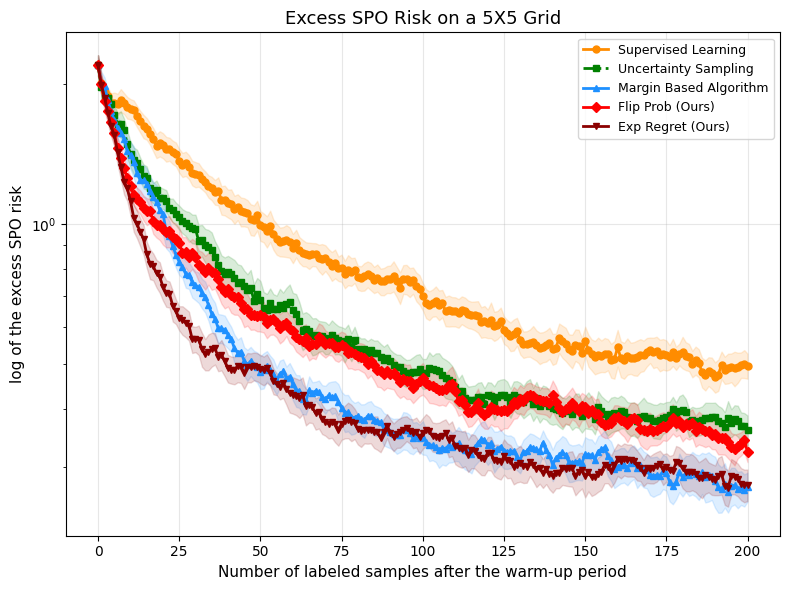

Saved: results_sp5x5_deg1_n0.25_clust1.00.png


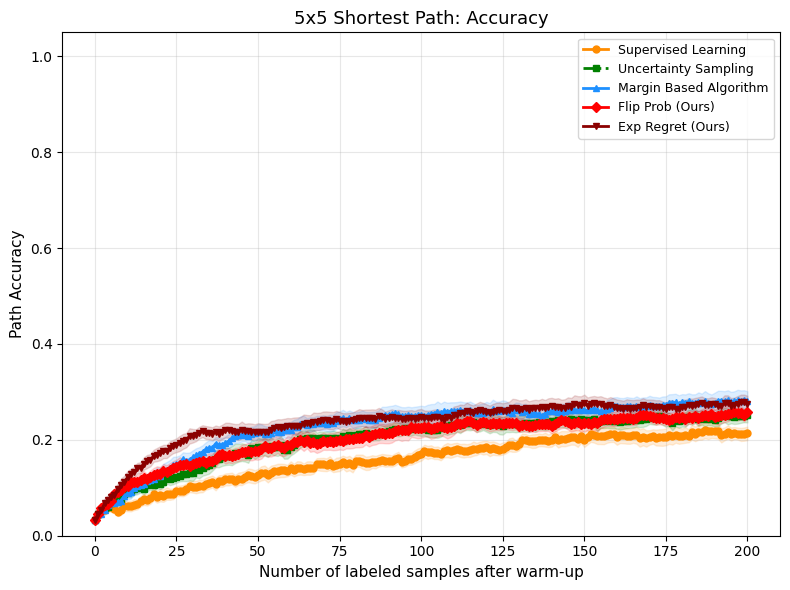

Saved: accuracy_sp5x5_deg1_n0.25_clust1.00.png


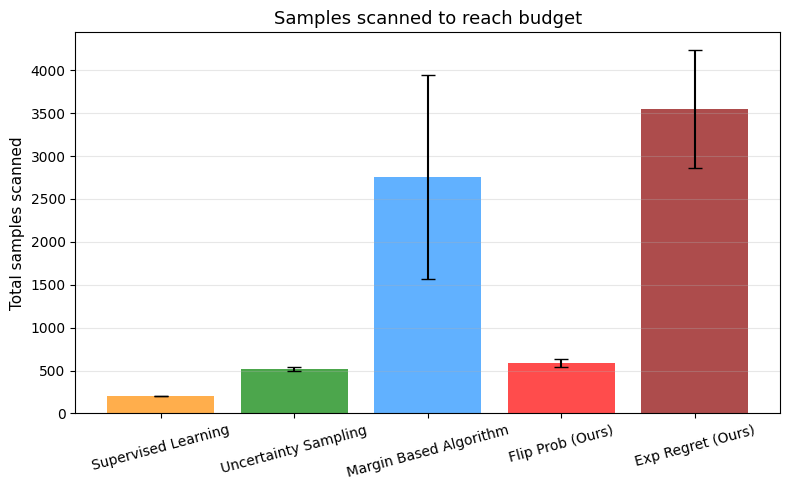

Saved: scans_sp5x5_deg1_n0.25_clust1.00.png

Summary: 5x5, deg=1, noise=0.25, clustering=1.00, 25 runs
  Method               Final Excess    Final Acc  Avg Scans
  ----------------------------------------------------------
  supervise          0.4959+/-0.0936  0.213+/-0.043  200
  uncertainty        0.3605+/-0.0835  0.251+/-0.044  517
  margin             0.2727+/-0.0595  0.281+/-0.061  2756
  flip               0.3237+/-0.0479  0.257+/-0.038  589
  regret             0.2754+/-0.0652  0.275+/-0.051  3544

  Mean excess per step (supervise vs margin):
  step   supervise      margin         ratio(S/M)
  0      2.1938         2.1938         1.00      
  20     1.4768         1.0532         1.40      
  40     1.1097         0.5790         1.92      
  60     0.8883         0.4528         1.96      
  80     0.7679         0.3873         1.98      
  100    0.7003         0.3484         2.01      
  120    0.6121         0.3345         1.83      
  140    0.5394         0.3038         1.7

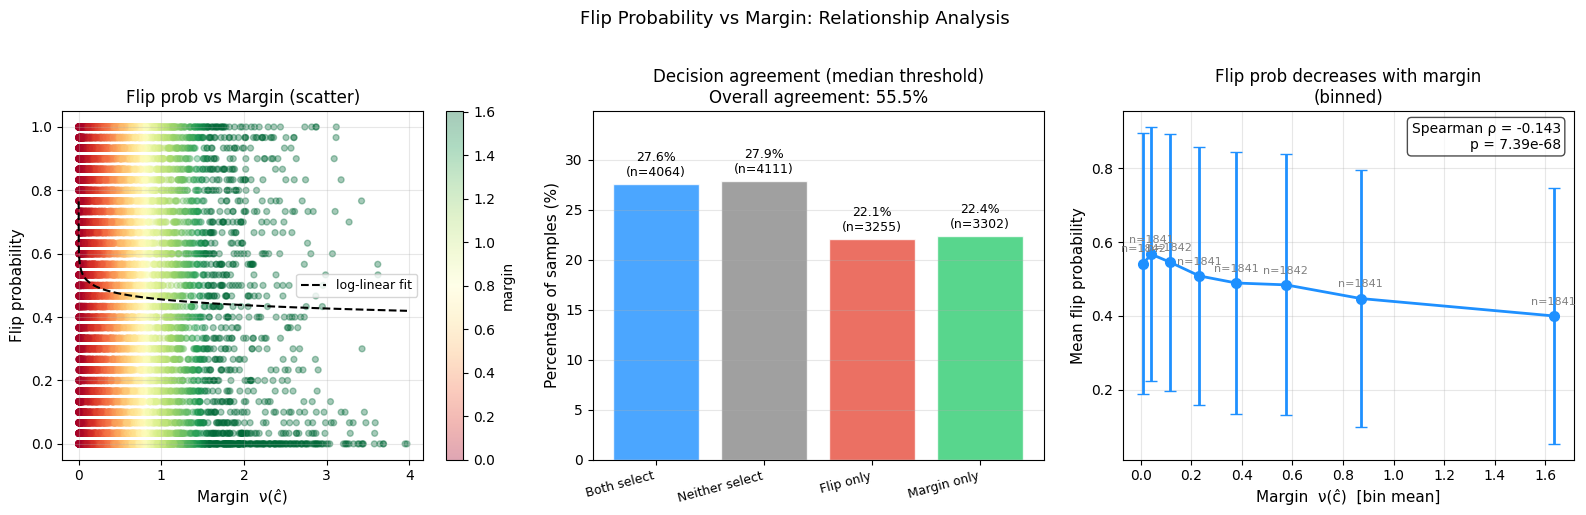

Saved: flip_vs_margin_sp5x5_deg1_n0.25_clust1.00.png

  Flip Probability vs Margin: Numerical Summary
  Samples analyzed : 14732
  Margin   — mean: 0.4825, median: 0.3008, std: 0.5472
  Flip prob — mean: 0.4981, median: 0.5000, std: 0.3545

  Decision agreement (at median thresholds):
    Both select   : 4064  ( 27.6%)
    Neither select: 4111  ( 27.9%)
    Flip only     : 3255  ( 22.1%)
    Margin only   : 3302  ( 22.4%)
    Overall agree : 55.5%

  Spearman rank correlation (margin vs flip prob):
    ρ = -0.1427,  p-value = 7.3938e-68

  Agreement rate by margin quartile:
  Quartile     Margin range           Agree %    n
  Q1 (p0-p25)  [0.000, 0.069]    56.7%     3683
  Q2 (p25-p50)  [0.069, 0.301]    53.6%     3683
  Q3 (p50-p75)  [0.301, 0.700]    52.2%     3683
  Q4 (p75-p100)  [0.700, 3.971]    59.4%     3683



In [31]:
results = run_experiment(
    mode='5x5',
    model_type='linear',
    #methods=['supervise', 'margin', 'flip', 'regret'],
    n_runs=25,
    stream_clustering=1.0,
    verbose=True,
)